## Floquet Time Crystals

In [ ]:
import numpy as np
from scipy.sparse import kron, eye, csc_matrix
from scipy.sparse.linalg import expm
import matplotlib.pyplot as plt

#Vamos a utilizar matrices sparse para hacer más eficiente el programa
# Definimos las matrices de Pauli y la identidad como matrices sparse
sx = csc_matrix(np.array([[0, 1], [1, 0]], dtype=complex))  # Pauli_X
sz = csc_matrix(np.array([[1, 0], [0, -1]], dtype=complex)) # Pauli_Z
id2 = csc_matrix(np.eye(2, dtype=complex))

def prod_kron_n(ops): #Calcula el producto de una lista de operadores.
    result = ops[0]   #ops: operadores (matrices) en cada sitio
    for op in ops[1:]:
        result = kron(result, op)
    return result

def op_local(op, sit, L): #Crea un operador local que actúa sólo en un sitio y como identidad en el resto.
                           #op: operador (sx o sz)
                           #sit: índice del sitio
                           #L: número total de sitios
    ops = [id2] * L
    ops[sit] = op
    return prod_kron_n(ops)

def op_ady(op1, op2, sit, L):   #Crea un operador que actúa sobre los sitios adyacentes (vecinos).
    ops = [id2] * L
    ops[sit] = op1
    ops[sit + 1] = op2
    return prod_kron_n(ops)

def H_MBL(L, J=1.0, hz_max=1.0, hx_max=0.3, seed=None):
    #Construye el Hamiltoniano de MBL.

    if seed is not None:
        np.random.seed(seed)

    H = csc_matrix((2**L, 2**L), dtype=complex)

    # Campo en dirección z
    hz = np.random.uniform(0, hz_max, size=L)
    for i in range(L):
        H += hz[i] * op_local(sz, i, L)

    # Campo en dirección x
    hx = np.random.uniform(0, hx_max, size=L)
    for i in range(L):
        H += hx[i] * op_local(sx, i, L)

    # Interacción entre vecinos
    Ji = np.random.uniform(J/2, 3*J/2, size=L - 1)
    for i in range(L - 1):
        H += Ji[i] * op_ady(sz, sz, i, L)

    return H

def sigma_x_sum(L):

    return sum(op_local(sx, i, L) for i in range(L))

def op_floquet(L, t0, t1, J, hz, hx, seed=None):

    #Construye el operador unitario de Floquet:
    #U = exp(-i t0 H_MBL) · exp(-i t1 ∑ σ^x_i)

    Hmbl = H_MBL(L, J=J, hz_max=hz, hx_max=hx, seed=seed)
    Hx = sigma_x_sum(L)

    U1 = expm(-1j * t0 * Hmbl)  # evolución bajo H_MBL
    U2 = expm(-1j * t1 * Hx)
    return U1 @ U2


Consideramos sistemas unidimensionales de espín 1/2 con unitarios de Floquet de la forma:
$$ U = exp(-i t_0H_{MBL}) exp(-it_1 \sum_i σ_i^x) $$


Necesitamos expresar de forma correcta a U

In [ ]:
def est_ini(L, theta=np.pi/8): #Construimos el estado inicial:|ψ⟩ = ⊗_i (cos(θ)|0⟩ + sin(θ)|1⟩)

    up = np.array([1, 0], dtype=complex)
    down = np.array([0, 1], dtype=complex)
    psi_sit = np.cos(theta) * up + np.sin(theta) * down

    psi = psi_sit
    for _ in range(L - 1):   #usamos _ para que la acción se repita L-1 veces, ya que comenzamos en el primer sitio
        psi = np.kron(psi, psi_sit)
    return psi


def med_mag_z(psi, L):  #Calcula ⟨σ^z_i⟩ para cada sitio i del estado psi.
    mz = []
    for i in range(L):
        Sz_i = op_local(sz, i, L)
        mz.append(np.real(np.vdot(psi, Sz_i @ psi)))
    return np.array(mz)

def med_mag_x(psi, L):  #Calcula ⟨σ^z_i⟩ para cada sitio i del estado psi.
    mx = [] # Initialize mx as an empty list
    for i in range(L):
        Sx_i = op_local(sx, i, L)
        mx.append(np.real(np.vdot(psi, Sx_i @ psi))) # Append to mx instead of mz
    return np.array(mx)



#Definimos la descomposición de Schmidt
def schmidt_desc(psi, L):
  dim= 2**(L//2) #Elegimos esta división del sistema en dos partes justo a la mitad
  psi_matrix= psi.reshape(dim, -1)
  u, s, vh = np.linalg.svd(psi_matrix, full_matrices=False)
  return s


def entropia_entrelazamiento(s_vals):
    """Calcula la entropía de von Neumann a partir de los coeficientes de Schmidt s_vals."""
    p = s_vals**2
    p = p[p > 1e-12]  # quitar ceros numéricos
    return -np.sum(p * np.log(p))

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


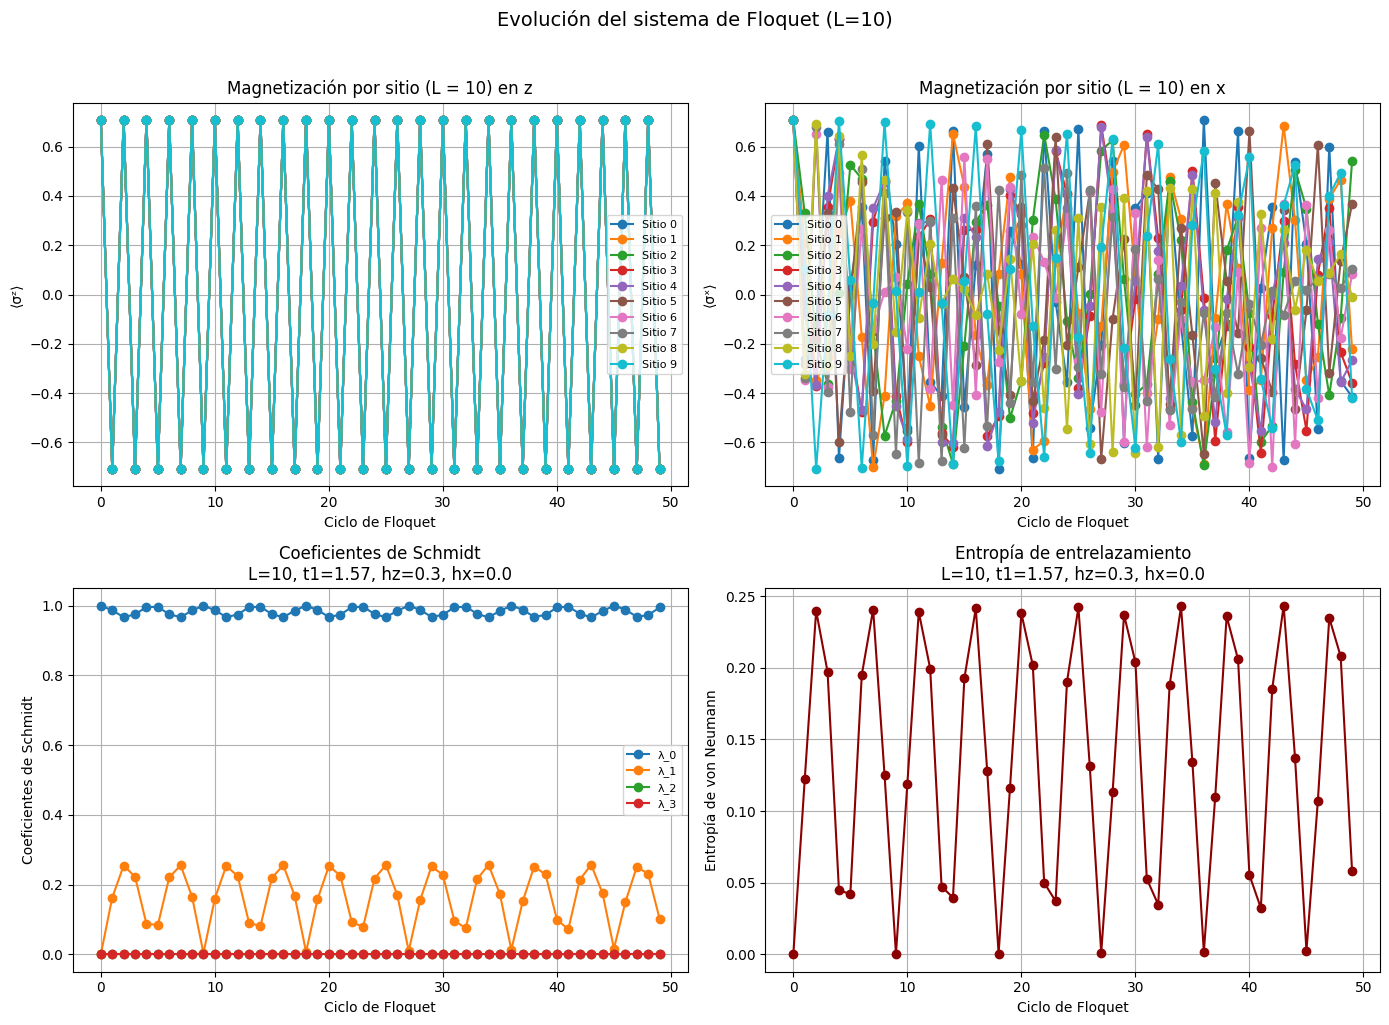

In [ ]:
#Parámetros del sistema
L =  10            # número de sitios (<= 10)
t0 = 1.0          # tiempo bajo H_MBL
t1 = np.pi / 2
J = 1.0           # fuerza de acoplamiento
hz = 0.3          # amplitud en z
hx = 0.0          # amplitud en x
n_pasos = 50      # ciclos de evolución

#Simulación de Floquet
U = op_floquet(L, t0, t1, J, hz, hx, seed=123)
psi = est_ini(L)

magneti_z = []
magneti_x = []
schmidt_hist=[]

for paso in range(n_pasos):
    mz = med_mag_z(psi, L)
    magneti_z.append(mz)

    mx = med_mag_x(psi, L)
    magneti_x.append(mx)

    s_vals=schmidt_desc(psi, L)
    schmidt_hist.append(s_vals)
    psi = U @ psi

magneti_z = np.array(magneti_z)
magneti_x = np.array(magneti_x)

# Calcular la entropía en cada paso
entropias = [entropia_entrelazamiento(s) for s in schmidt_hist]


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# (1) Magnetización en z
for i in range(L):
    axes[0].plot(magneti_z[:, i], marker='o', label=f'Sitio {i}')
axes[0].set_xlabel('Ciclo de Floquet')
axes[0].set_ylabel('⟨σᶻ⟩')
axes[0].set_title(f'Magnetización por sitio (L = {L}) en z')
axes[0].grid(True)
axes[0].legend(fontsize=8, loc='best')

# (2) Magnetización en x
for i in range(L):
    axes[1].plot(magneti_x[:, i], marker='o', label=f'Sitio {i}')
axes[1].set_xlabel('Ciclo de Floquet')
axes[1].set_ylabel('⟨σˣ⟩')
axes[1].set_title(f'Magnetización por sitio (L = {L}) en x')
axes[1].grid(True)
axes[1].legend(fontsize=8, loc='best')

# (3) Primeros coeficientes de Schmidt
for k in range(4):
    vals_k = [s[k] if len(s) > k else 0 for s in schmidt_hist]
    axes[2].plot(vals_k, marker='o', label=f'λ_{k}')
axes[2].set_title(f'Coeficientes de Schmidt\nL={L}, t1={t1:.2f}, hz={hz}, hx={hx}')
axes[2].set_xlabel('Ciclo de Floquet')
axes[2].set_ylabel('Coeficientes de Schmidt')
axes[2].grid(True)
axes[2].legend(fontsize=8, loc='best')

# (4) Entropía de entrelazamiento
axes[3].plot(entropias, marker='o', color="darkred")
axes[3].set_xlabel('Ciclo de Floquet')
axes[3].set_ylabel('Entropía de von Neumann')
axes[3].set_title(f'Entropía de entrelazamiento\nL={L}, t1={t1:.2f}, hz={hz}, hx={hx}')
axes[3].grid(True)

# Ajuste general de la figura
plt.suptitle(f"Evolución del sistema de Floquet (L={L})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

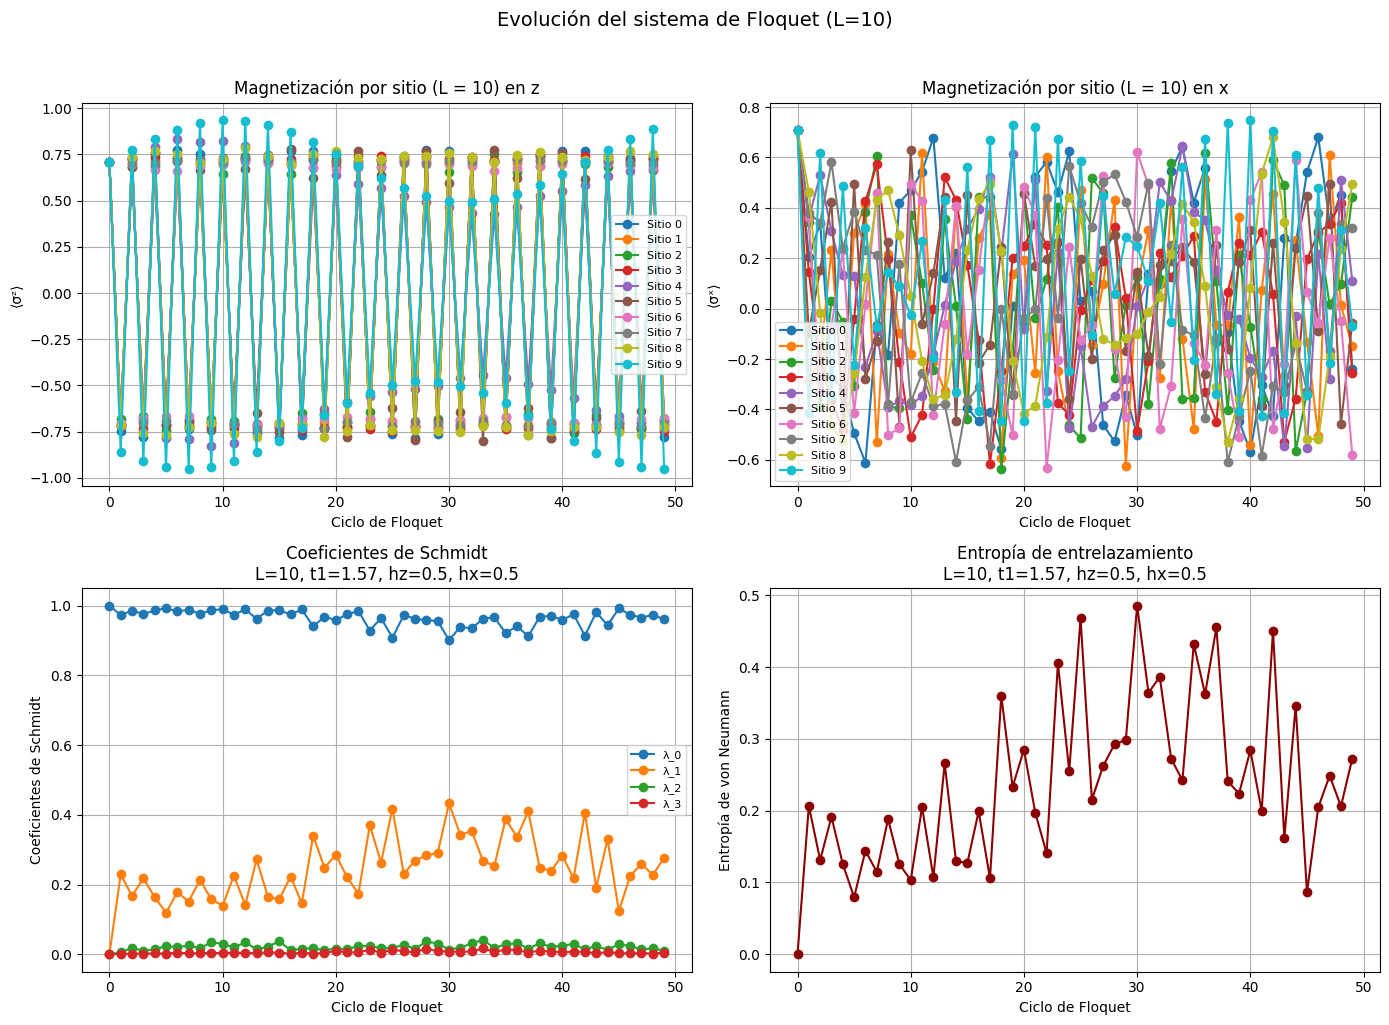

In [ ]:
#Parámetros del sistema
L =  10            # número de sitios (<= 10)
t0 = 1.0          # tiempo bajo H_MBL
t1 = np.pi / 2
J = 3           # fuerza de acoplamiento
hz = 0.5          # amplitud en z
hx = 0.5          # amplitud en x
n_pasos = 50      # ciclos de evolución

#Simulación de Floquet
U = op_floquet(L, t0, t1, J, hz, hx, seed=321)
psi = est_ini(L)

magneti_z = []
magneti_x = []
schmidt_hist=[]

for paso in range(n_pasos):
    mz = med_mag_z(psi, L)
    magneti_z.append(mz)

    mx = med_mag_x(psi, L)
    magneti_x.append(mx)

    s_vals=schmidt_desc(psi, L)
    schmidt_hist.append(s_vals)
    psi = U @ psi

magneti_z = np.array(magneti_z)
magneti_x = np.array(magneti_x)

# Calcular la entropía en cada paso
entropias = [entropia_entrelazamiento(s) for s in schmidt_hist]


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# (1) Magnetización en z
for i in range(L):
    axes[0].plot(magneti_z[:, i], marker='o', label=f'Sitio {i}')
axes[0].set_xlabel('Ciclo de Floquet')
axes[0].set_ylabel('⟨σᶻ⟩')
axes[0].set_title(f'Magnetización por sitio (L = {L}) en z')
axes[0].grid(True)
axes[0].legend(fontsize=8, loc='best')

# (2) Magnetización en x
for i in range(L):
    axes[1].plot(magneti_x[:, i], marker='o', label=f'Sitio {i}')
axes[1].set_xlabel('Ciclo de Floquet')
axes[1].set_ylabel('⟨σˣ⟩')
axes[1].set_title(f'Magnetización por sitio (L = {L}) en x')
axes[1].grid(True)
axes[1].legend(fontsize=8, loc='best')

# (3) Primeros coeficientes de Schmidt
for k in range(4):
    vals_k = [s[k] if len(s) > k else 0 for s in schmidt_hist]
    axes[2].plot(vals_k, marker='o', label=f'λ_{k}')
axes[2].set_title(f'Coeficientes de Schmidt\nL={L}, t1={t1:.2f}, hz={hz}, hx={hx}')
axes[2].set_xlabel('Ciclo de Floquet')
axes[2].set_ylabel('Coeficientes de Schmidt')
axes[2].grid(True)
axes[2].legend(fontsize=8, loc='best')

# (4) Entropía de entrelazamiento
axes[3].plot(entropias, marker='o', color="darkred")
axes[3].set_xlabel('Ciclo de Floquet')
axes[3].set_ylabel('Entropía de von Neumann')
axes[3].set_title(f'Entropía de entrelazamiento\nL={L}, t1={t1:.2f}, hz={hz}, hx={hx}')
axes[3].grid(True)

# Ajuste general de la figura
plt.suptitle(f"Evolución del sistema de Floquet (L={L})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

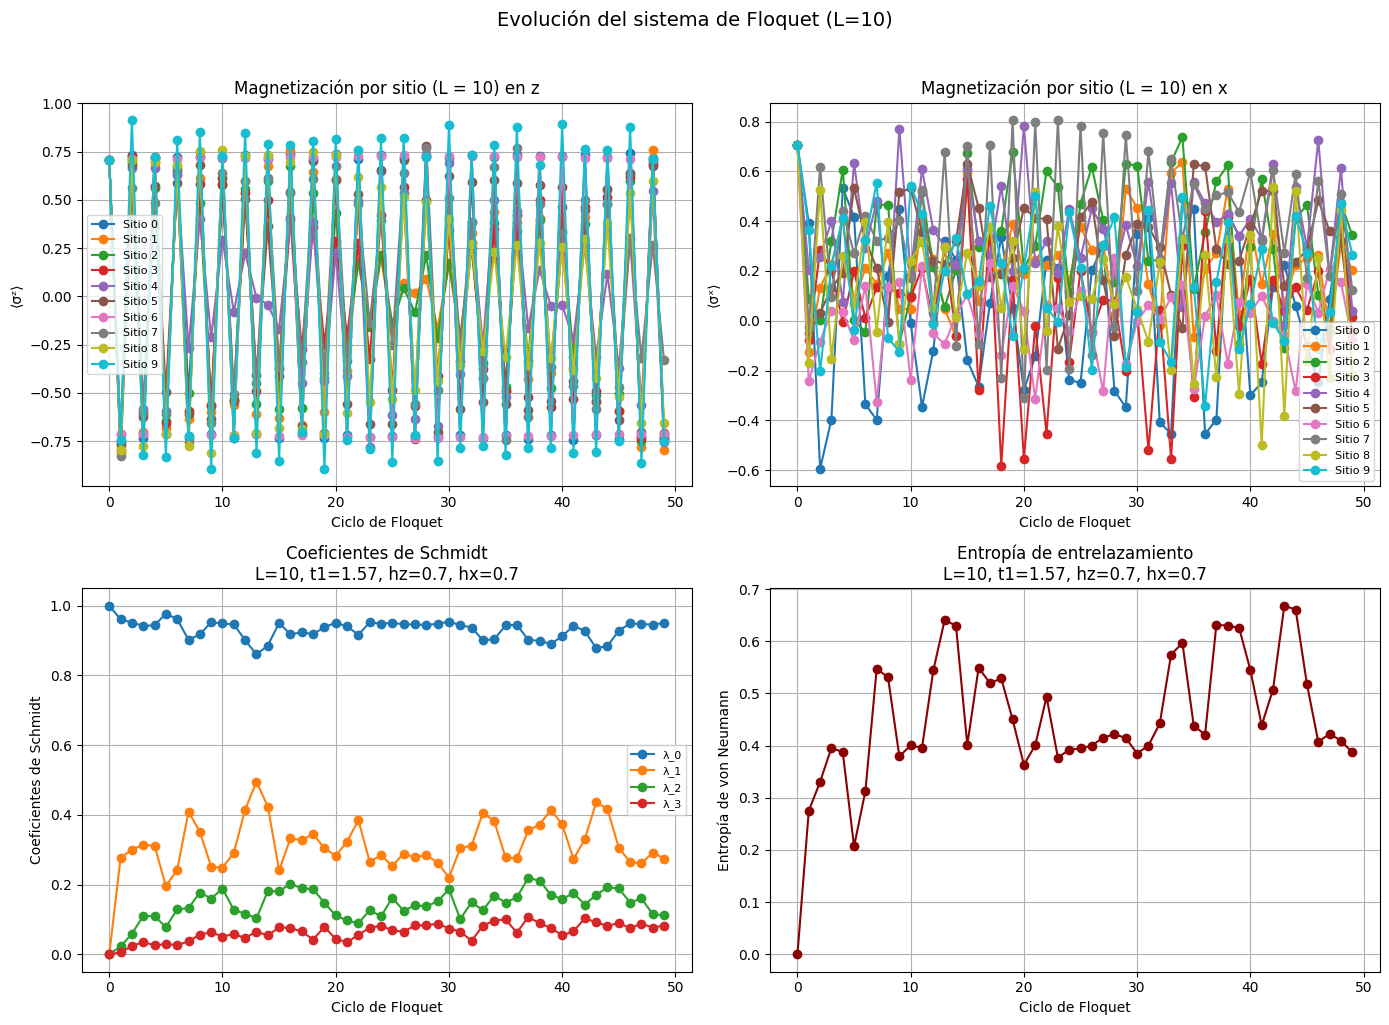

In [ ]:
#Parámetros del sistema
L =  10            # número de sitios (<= 10)
t0 = 1.0          # tiempo bajo H_MBL
t1 = np.pi / 2
J = 1.0           # fuerza de acoplamiento
hz = 0.7          # amplitud en z
hx = 0.7          # amplitud en x
n_pasos = 50      # ciclos de evolución

#Simulación de Floquet
U = op_floquet(L, t0, t1, J, hz, hx, seed=3)
psi = est_ini(L)

magneti_z = []
magneti_x = []
schmidt_hist=[]

for paso in range(n_pasos):
    mz = med_mag_z(psi, L)
    magneti_z.append(mz)

    mx = med_mag_x(psi, L)
    magneti_x.append(mx)

    s_vals=schmidt_desc(psi, L)
    schmidt_hist.append(s_vals)
    psi = U @ psi

magneti_z = np.array(magneti_z)
magneti_x = np.array(magneti_x)

# Calcular la entropía en cada paso
entropias = [entropia_entrelazamiento(s) for s in schmidt_hist]


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# (1) Magnetización en z
for i in range(L):
    axes[0].plot(magneti_z[:, i], marker='o', label=f'Sitio {i}')
axes[0].set_xlabel('Ciclo de Floquet')
axes[0].set_ylabel('⟨σᶻ⟩')
axes[0].set_title(f'Magnetización por sitio (L = {L}) en z')
axes[0].grid(True)
axes[0].legend(fontsize=8, loc='best')

# (2) Magnetización en x
for i in range(L):
    axes[1].plot(magneti_x[:, i], marker='o', label=f'Sitio {i}')
axes[1].set_xlabel('Ciclo de Floquet')
axes[1].set_ylabel('⟨σˣ⟩')
axes[1].set_title(f'Magnetización por sitio (L = {L}) en x')
axes[1].grid(True)
axes[1].legend(fontsize=8, loc='best')

# (3) Primeros coeficientes de Schmidt
for k in range(4):
    vals_k = [s[k] if len(s) > k else 0 for s in schmidt_hist]
    axes[2].plot(vals_k, marker='o', label=f'λ_{k}')
axes[2].set_title(f'Coeficientes de Schmidt\nL={L}, t1={t1:.2f}, hz={hz}, hx={hx}')
axes[2].set_xlabel('Ciclo de Floquet')
axes[2].set_ylabel('Coeficientes de Schmidt')
axes[2].grid(True)
axes[2].legend(fontsize=8, loc='best')

# (4) Entropía de entrelazamiento
axes[3].plot(entropias, marker='o', color="darkred")
axes[3].set_xlabel('Ciclo de Floquet')
axes[3].set_ylabel('Entropía de von Neumann')
axes[3].set_title(f'Entropía de entrelazamiento\nL={L}, t1={t1:.2f}, hz={hz}, hx={hx}')
axes[3].grid(True)

# Ajuste general de la figura
plt.suptitle(f"Evolución del sistema de Floquet (L={L})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


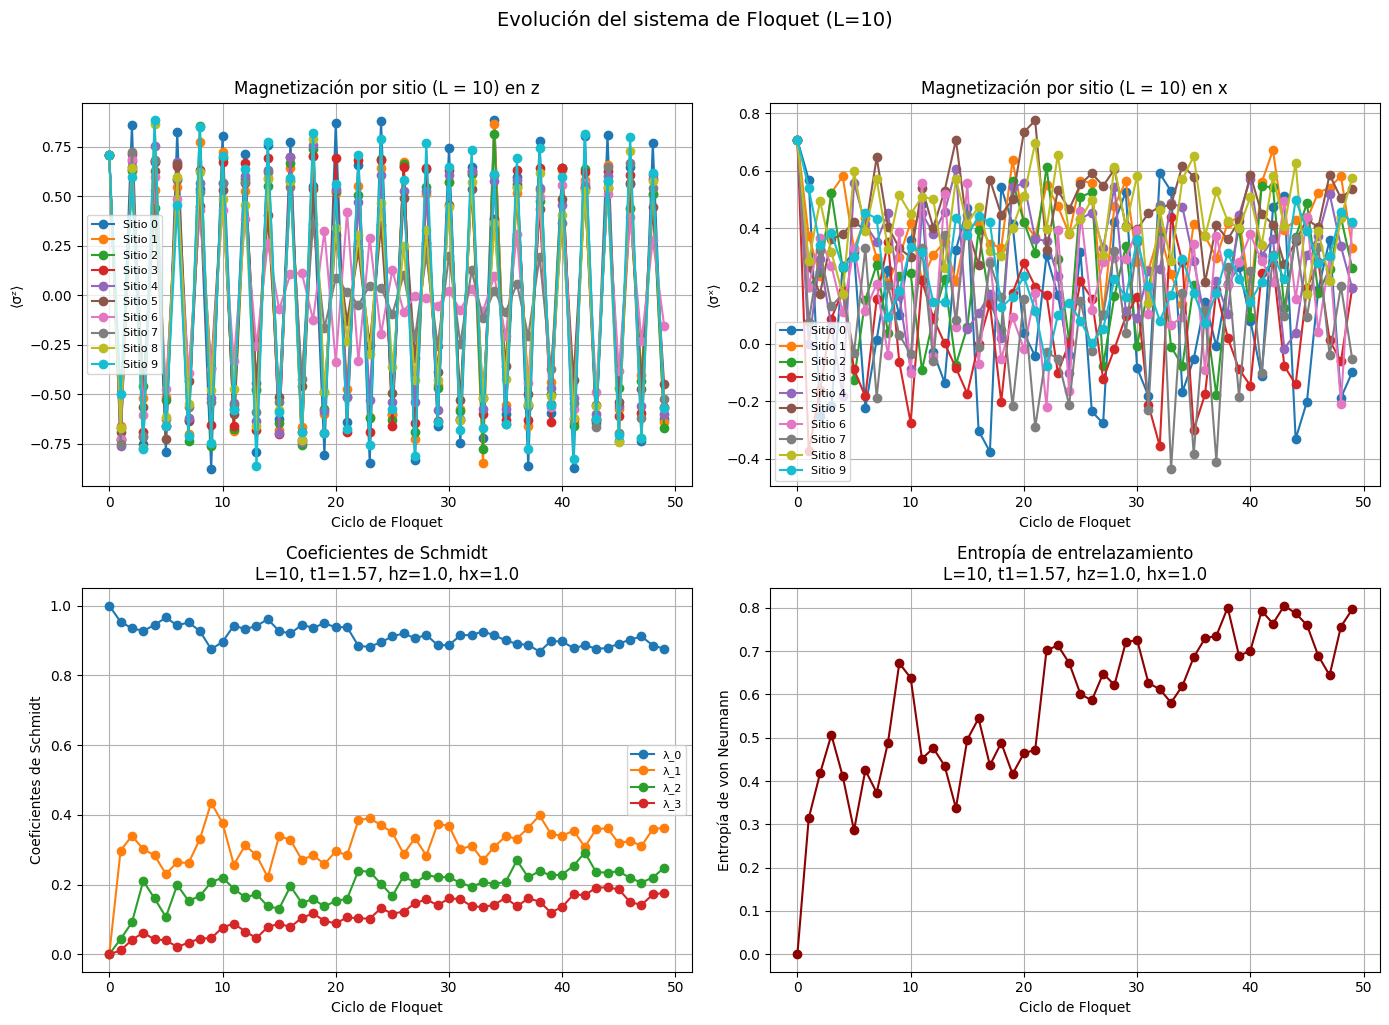

In [ ]:
#Parámetros del sistema
L =  10            # número de sitios (<= 10)
t0 = 1.0          # tiempo bajo H_MBL
t1 = np.pi / 2
J = 1.0           # fuerza de acoplamiento
hz = 1.0          # amplitud en z
hx = 1.0          # amplitud en x
n_pasos = 50      # ciclos de evolución

#Simulación de Floquet
U = op_floquet(L, t0, t1, J, hz, hx, seed=123)
psi = est_ini(L)

magneti_z = []
magneti_x = []
schmidt_hist=[]

for paso in range(n_pasos):
    mz = med_mag_z(psi, L)
    magneti_z.append(mz)

    mx = med_mag_x(psi, L)
    magneti_x.append(mx)

    s_vals=schmidt_desc(psi, L)
    schmidt_hist.append(s_vals)
    psi = U @ psi

magneti_z = np.array(magneti_z)
magneti_x = np.array(magneti_x)

# Calcular la entropía en cada paso
entropias = [entropia_entrelazamiento(s) for s in schmidt_hist]


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# (1) Magnetización en z
for i in range(L):
    axes[0].plot(magneti_z[:, i], marker='o', label=f'Sitio {i}')
axes[0].set_xlabel('Ciclo de Floquet')
axes[0].set_ylabel('⟨σᶻ⟩')
axes[0].set_title(f'Magnetización por sitio (L = {L}) en z')
axes[0].grid(True)
axes[0].legend(fontsize=8, loc='best')

# (2) Magnetización en x
for i in range(L):
    axes[1].plot(magneti_x[:, i], marker='o', label=f'Sitio {i}')
axes[1].set_xlabel('Ciclo de Floquet')
axes[1].set_ylabel('⟨σˣ⟩')
axes[1].set_title(f'Magnetización por sitio (L = {L}) en x')
axes[1].grid(True)
axes[1].legend(fontsize=8, loc='best')

# (3) Primeros coeficientes de Schmidt
for k in range(4):
    vals_k = [s[k] if len(s) > k else 0 for s in schmidt_hist]
    axes[2].plot(vals_k, marker='o', label=f'λ_{k}')
axes[2].set_title(f'Coeficientes de Schmidt\nL={L}, t1={t1:.2f}, hz={hz}, hx={hx}')
axes[2].set_xlabel('Ciclo de Floquet')
axes[2].set_ylabel('Coeficientes de Schmidt')
axes[2].grid(True)
axes[2].legend(fontsize=8, loc='best')

# (4) Entropía de entrelazamiento
axes[3].plot(entropias, marker='o', color="darkred")
axes[3].set_xlabel('Ciclo de Floquet')
axes[3].set_ylabel('Entropía de von Neumann')
axes[3].set_title(f'Entropía de entrelazamiento\nL={L}, t1={t1:.2f}, hz={hz}, hx={hx}')
axes[3].grid(True)

# Ajuste general de la figura
plt.suptitle(f"Evolución del sistema de Floquet (L={L})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()